# EDA


train.csv shape: (35549, 15)
taxonomy.csv shape: (234, 5)

train.csv columns:
['primary_label', 'secondary_labels', 'type', 'latitude', 'longitude', 'scientific_name', 'common_name', 'class_name', 'inat_taxon_id', 'author', 'license', 'rating', 'url', 'filename', 'collection']


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat



Missing values in train.csv:


primary_label       0
secondary_labels    0
type                0
latitude            0
longitude           0
scientific_name     0
common_name         0
class_name          0
inat_taxon_id       0
author              0
license             0
rating              0
url                 0
filename            0
collection          0
dtype: int64


Using label column: primary_label
Number of unique classes: 206


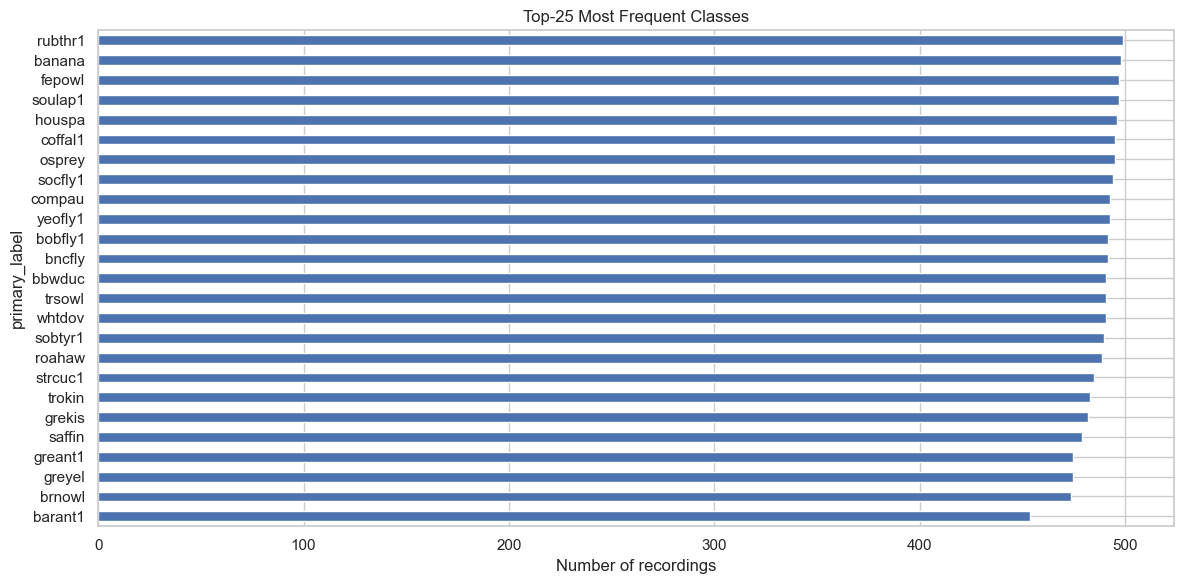


Audio files found: 35549
Example file: birdclef-2026/train_audio/crebec1/XC119358.ogg

Duration stats (sample):


count    2000.000000
mean       33.190400
std        44.761951
min         0.036000
10%         5.901319
25%        10.560383
50%        20.836438
75%        39.288156
90%        71.920319
max       821.028563
Name: duration_sec, dtype: float64

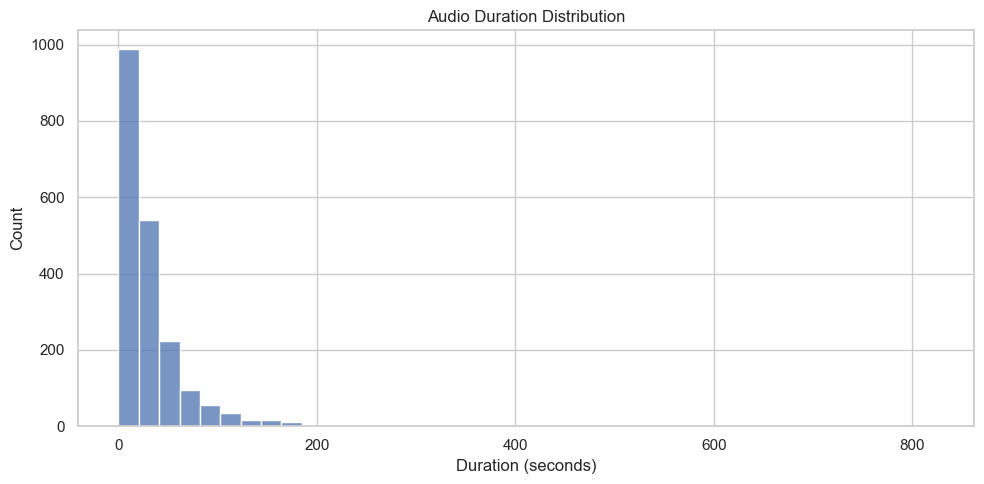


Random sample: iNat1212314.ogg
Sample rate: 32000 | Duration: 4.0 sec


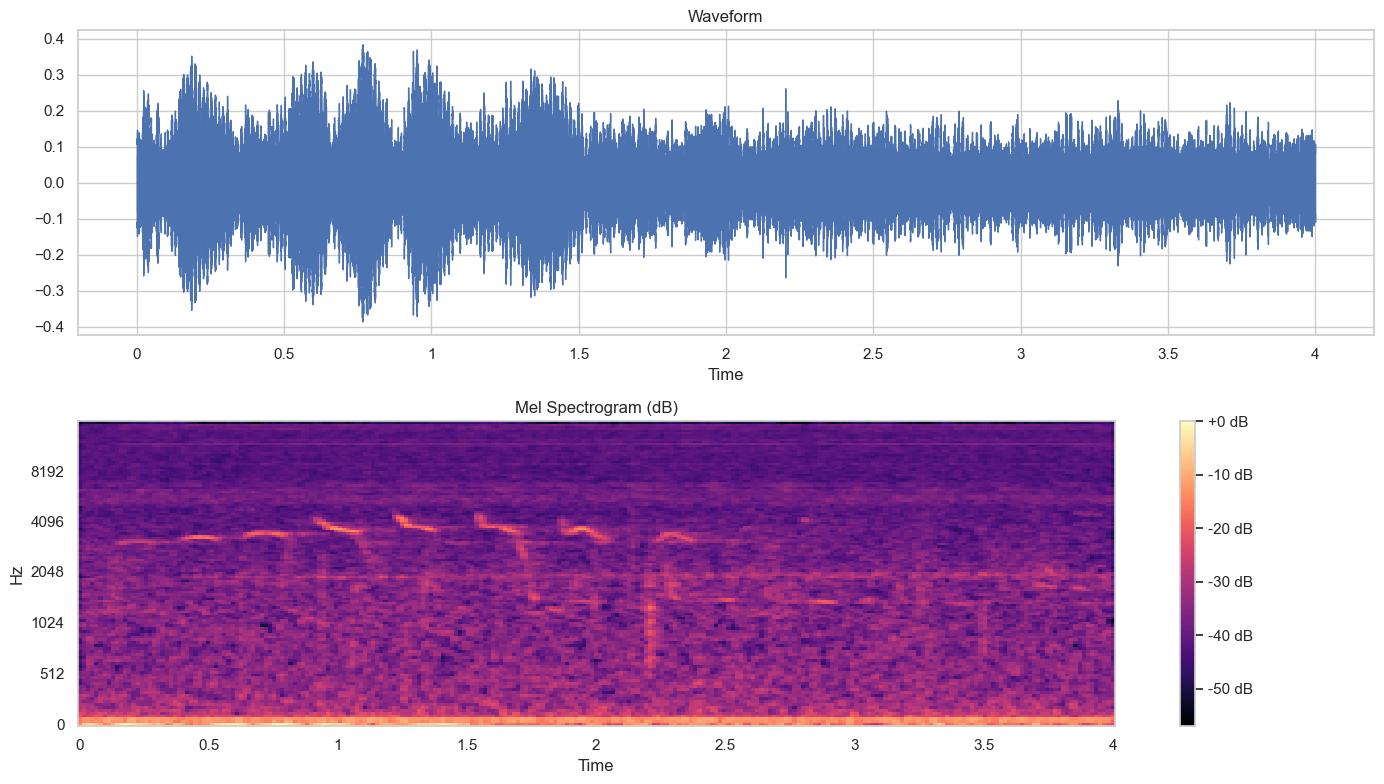

In [ ]:
from pathlib import Path
import random
import subprocess
import sys
import zipfile

ROOT = Path("birdclef-2026")


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

TRAIN_CSV = ROOT / "train.csv"
TAXONOMY_CSV = ROOT / "taxonomy.csv"
TRAIN_AUDIO_DIR = ROOT / "train_audio"

train_df = pd.read_csv(TRAIN_CSV)
taxonomy_df = pd.read_csv(TAXONOMY_CSV)

print("train.csv shape:", train_df.shape)
print("taxonomy.csv shape:", taxonomy_df.shape)
print("\ntrain.csv columns:")
print(train_df.columns.tolist())

display(train_df.head())

print("\nMissing values in train.csv:")
display(train_df.isna().sum().sort_values(ascending=False).head(15))

possible_label_cols = ["primary_label", "species", "scientific_name", "label"]
label_col = next((c for c in possible_label_cols if c in train_df.columns), None)

if label_col is None:
    print("\nCould not find a standard label column.")
    print("Please set `label_col` manually from:", train_df.columns.tolist())
else:
    print(f"\nUsing label column: {label_col}")
    class_counts = train_df[label_col].value_counts()
    print("Number of unique classes:", class_counts.shape[0])

    plt.figure(figsize=(12, 6))
    class_counts.head(25).sort_values().plot(kind="barh")
    plt.title("Top-25 Most Frequent Classes")
    plt.xlabel("Number of recordings")
    plt.ylabel(label_col)
    plt.tight_layout()
    plt.show()


all_audio_files = list(TRAIN_AUDIO_DIR.rglob("*.ogg"))
if len(all_audio_files) == 0:
    all_audio_files = list(TRAIN_AUDIO_DIR.rglob("*.wav"))

print("\nAudio files found:", len(all_audio_files))
if len(all_audio_files) > 0:
    print("Example file:", all_audio_files[0])

try:
    import soundfile as sf

    sample_for_duration = all_audio_files if len(all_audio_files) <= 2000 else random.sample(all_audio_files, 2000)

    durations = []
    for fp in sample_for_duration:
        try:
            info = sf.info(str(fp))
            durations.append(info.frames / info.samplerate)
        except Exception:
            continue

    if len(durations) > 0:
        duration_series = pd.Series(durations, name="duration_sec")
        print("\nDuration stats (sample):")
        display(duration_series.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

        plt.figure(figsize=(10, 5))
        sns.histplot(duration_series, bins=40)
        plt.title("Audio Duration Distribution")
        plt.xlabel("Duration (seconds)")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()
    else:
        print("\nNo durations could be read.")
except Exception as e:
    print("\nSkipping duration section:", e)


try:
    import librosa
    import librosa.display

    if len(all_audio_files) > 0:
        audio_path = random.choice(all_audio_files)
        y, sr = librosa.load(audio_path, sr=None, mono=True)

        print("\nRandom sample:", audio_path.name)
        print("Sample rate:", sr, "| Duration:", round(len(y) / sr, 2), "sec")

        fig, axes = plt.subplots(2, 1, figsize=(14, 8))

        librosa.display.waveshow(y, sr=sr, ax=axes[0])
        axes[0].set_title("Waveform")

        S_db = librosa.power_to_db(
            librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128),
            ref=np.max
        )
        librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel", ax=axes[1])
        axes[1].set_title("Mel Spectrogram (dB)")
        plt.colorbar(axes[1].collections[0], ax=axes[1], format="%+2.0f dB")

        plt.tight_layout()
        plt.show()
    else:
        print("\nNo audio files.")
except Exception as e:
    print("\nSkipping waveform/spectrogram section:", e)

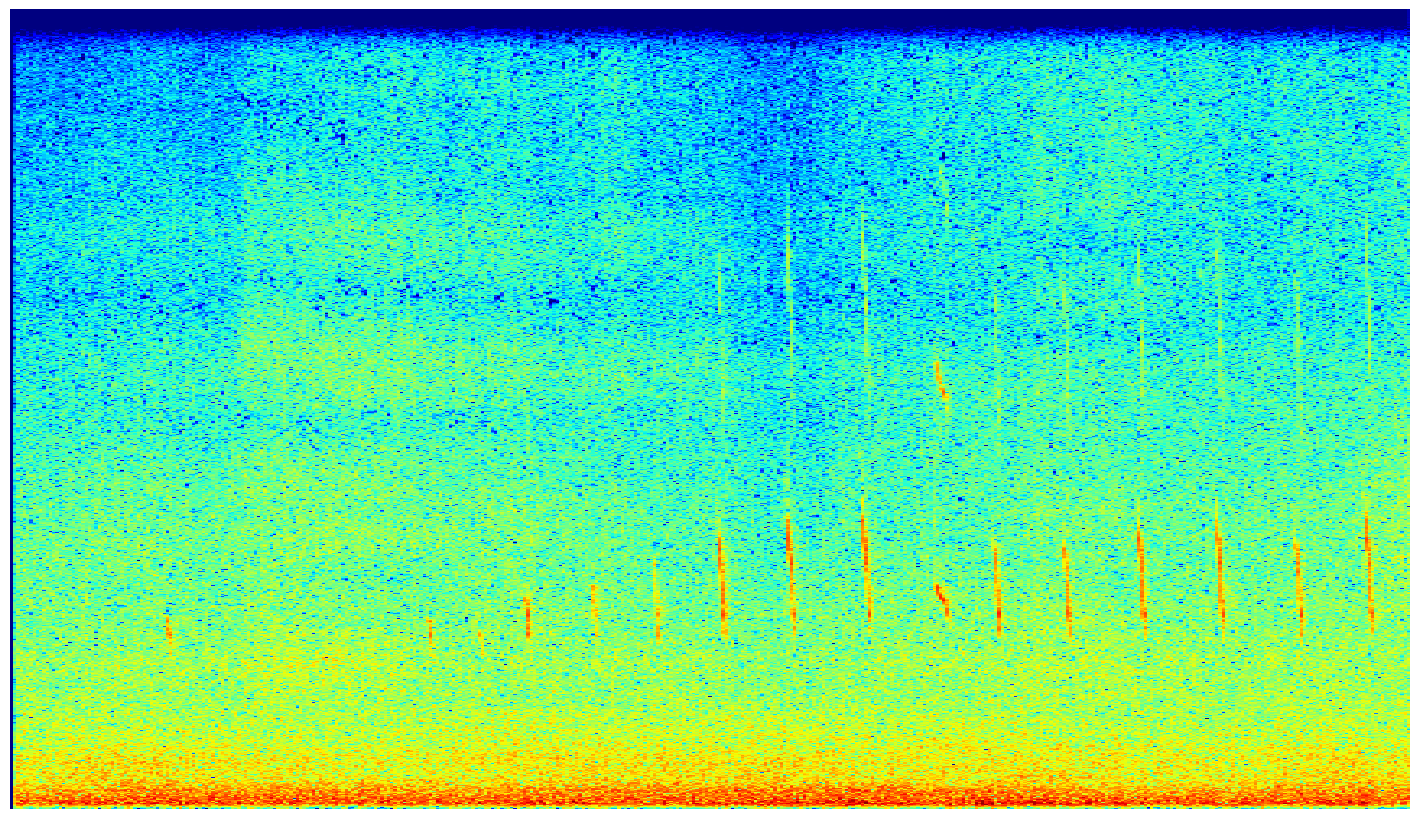

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

y, sr = librosa.load(fp, sr=22050, mono=True)
y = y[: int(20 * sr)] 

n_fft = 2048
hop_length = 1024
S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length)) ** 2
S_db = librosa.power_to_db(S, ref=np.max)

fig, ax = plt.subplots(figsize=(14, 8))

librosa.display.specshow(S_db, sr=sr, hop_length=hop_length, cmap="jet", ax=ax)

ax.axis("off")

plt.subplots_adjust(left=0, right=1, bottom=0, top=1)

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from pathlib import Path
import random
from PIL import Image
from tqdm.auto import tqdm

def generate_clean_spectrograms(
    data,
    chunk_length=7.0,
    sr=32000,
    save_dir_mel=None,
    save_dir_2d=None,
    train_audio_root="birdclef-2026/train_audio",
    n_mels=128,
    n_fft=1024,
    hop_length=256,
    fmin=50,
    fmax=14000,
    power=2.0,
    top_db=80,
    random_chunk=True,
    seed=42,
    mel_cmap="magma",
    linear_cmap="magma",
):
    random.seed(seed)
    np.random.seed(seed)

    if isinstance(data, (str, Path)):
        data = [data]

    train_audio_root = Path(train_audio_root).resolve()

    if save_dir_mel:
        Path(save_dir_mel).mkdir(parents=True, exist_ok=True)
    if save_dir_2d:
        Path(save_dir_2d).mkdir(parents=True, exist_ok=True)

    def _target_path(save_root, fp):
        fp = Path(fp).resolve()
        try:
            rel = fp.relative_to(train_audio_root)
        except ValueError:
            rel = Path(fp.parent.name) / fp.name
        out = Path(save_root) / rel.with_suffix(".png")
        out.parent.mkdir(parents=True, exist_ok=True)
        return out

    def _save_fast_image(S_db, cmap, save_path):
        S_min, S_max = S_db.min(), S_db.max()
        S_norm = (S_db - S_min) / (S_max - S_min + 1e-8)
        
        S_norm = np.flipud(S_norm)
        
        img_rgb = (cmap(S_norm)[:, :, :3] * 255).astype(np.uint8)
        
        Image.fromarray(img_rgb).save(save_path)

    cmap_mel_obj = plt.get_cmap(mel_cmap)
    cmap_lin_obj = plt.get_cmap(linear_cmap)

    errors = []
    saved_count_mel = 0
    saved_count_2d = 0

    for fp in tqdm(data, desc="Generating spectrograms", unit="file"):
        try:
            fp = Path(fp)

            if not fp.exists():
                raise FileNotFoundError(f"Audio file not found: {fp}")

            total_duration = librosa.get_duration(path=str(fp))
            if total_duration <= 0:
                raise ValueError("Audio duration is zero or invalid")

            if total_duration <= chunk_length:
                start_time = 0.0
                duration = total_duration
            else:
                if random_chunk:
                    max_start = total_duration - chunk_length
                    start_time = random.uniform(0, max_start)
                else:
                    start_time = 0.0
                duration = chunk_length

            y, current_sr = librosa.load(
                str(fp),
                sr=sr,
                mono=True,
                offset=start_time,
                duration=duration,
            )

            if y.size == 0:
                raise ValueError("Loaded empty audio chunk")

            expected_samples = int(chunk_length * sr)
            if len(y) < expected_samples:
                padding_length = expected_samples - len(y)
                y = np.pad(y, (0, padding_length), mode='constant')

            peak = np.max(np.abs(y))
            if peak > 0:
                y = y / peak

            S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length, window="hann")) ** power
            S_db = librosa.power_to_db(S, ref=np.max, top_db=top_db)

            if save_dir_2d:
                save_path_2d = _target_path(save_dir_2d, fp)
                _save_fast_image(S_db, cmap_lin_obj, save_path_2d)
                saved_count_2d += 1
            else:
                fig_2d, ax_2d = plt.subplots(figsize=(12, 6), dpi=150)
                librosa.display.specshow(S_db, sr=current_sr, hop_length=hop_length, x_axis="time", y_axis="linear", cmap=linear_cmap, ax=ax_2d)
                ax_2d.axis("off")
                fig_2d.subplots_adjust(left=0, right=1, bottom=0, top=1)
                plt.show()
                plt.close(fig_2d)

            safe_fmax = min(fmax, current_sr // 2)

            S_mel = librosa.feature.melspectrogram(
                y=y,
                sr=current_sr,
                n_fft=n_fft,
                hop_length=hop_length,
                n_mels=n_mels,
                fmin=fmin,
                fmax=safe_fmax,
                power=power,
                window="hann",
            )
            S_mel_db = librosa.power_to_db(S_mel, ref=np.max, top_db=top_db)

            if save_dir_mel:
                save_path_mel = _target_path(save_dir_mel, fp)
                _save_fast_image(S_mel_db, cmap_mel_obj, save_path_mel)
                saved_count_mel += 1
            else:
                fig_mel, ax_mel = plt.subplots(figsize=(12, 6), dpi=150)
                librosa.display.specshow(S_mel_db, sr=current_sr, hop_length=hop_length, x_axis="time", y_axis="mel", fmin=fmin, fmax=safe_fmax, cmap=mel_cmap, ax=ax_mel)
                ax_mel.axis("off")
                fig_mel.subplots_adjust(left=0, right=1, bottom=0, top=1)
                plt.show()
                plt.close(fig_mel)

        except Exception as e:
            errors.append({"audio_file": str(fp), "error": str(e)})

    return {
        "saved_mel": saved_count_mel,
        "saved_2d": saved_count_2d,
        "errors": errors,
    }

files_to_process = list(Path("birdclef-2026/train_audio").rglob("*.ogg"))
dataset_path = Path("./dataset")
mel_path = dataset_path / "mel_spectrograms"
linear_path = dataset_path / "linear_spectrograms"
if not (mel_path.exists() and linear_path.exists()):
    result = generate_clean_spectrograms(
        files_to_process,
        chunk_length=7.0,
        sr=32000,
        save_dir_mel="dataset/mel_spectrograms",
        save_dir_2d="dataset/linear_spectrograms",
        train_audio_root="birdclef-2026/train_audio",
        n_mels=128,
        n_fft=1024,
        hop_length=256,
        fmin=50,
        fmax=14000,
        top_db=80,
        random_chunk=True,
        seed=42,
        mel_cmap="magma",
        linear_cmap="magma",
    )

In [ ]:
import copy
import pickle
import math
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.auto import tqdm
from sklearn.metrics import roc_auc_score, f1_score, label_ranking_average_precision_score

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

ROOT = Path("birdclef-2026")
SPECTROGRAM_DIR = Path("dataset/mel_spectrograms")

EPOCHS_FROZEN   = 3     
EPOCHS_UNFROZEN = 7   
BATCH_SIZE      = 32
NUM_WORKERS     = 0
VAL_RATIO       = 0.2
LR_FROZEN       = 1e-3 
LR_UNFROZEN     = 2e-4  
WEIGHT_DECAY    = 1e-4

# ── Ensemble ──
TOP_K_FOR_ENSEMBLE = 3

print(f"Device: {DEVICE}")
print(f"Spectrogram dir: {SPECTROGRAM_DIR}")
print(f"Frozen epochs: {EPOCHS_FROZEN}, Unfrozen epochs: {EPOCHS_UNFROZEN}")

Device: mps
Spectrogram dir: dataset/mel_spectrograms
Frozen epochs: 3, Unfrozen epochs: 7


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from pathlib import Path

class BirdSpectrogramDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform or transforms.Compose([
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]

        with Image.open(img_path) as img:
            image = img.convert("RGB")
            
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        label_tensor = torch.tensor(label, dtype=torch.float32)
        return image, label_tensor

spectrogram_root = Path("dataset/mel_spectrograms")
image_paths = sorted(spectrogram_root.rglob("*.png"))

if len(image_paths) == 0:
    print("No spectrogram PNG files found in dataset/mel_spectrograms.")
else:
    class_names = sorted({p.parent.name for p in image_paths})
    class_to_idx = {name: i for i, name in enumerate(class_names)}
    labels = [class_to_idx[p.parent.name] for p in image_paths]

    train_dataset = BirdSpectrogramDataset(image_paths=image_paths, labels=labels)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)

    for images, batch_labels in train_loader:
        print(f"Batch Image Shape: {images.shape}")
        print(f"Batch Label Shape: {batch_labels.shape}")
        print(f"Classes in mapping: {len(class_to_idx)}")
        break

Batch Image Shape: torch.Size([32, 3, 128, 876])
Batch Label Shape: torch.Size([32])
Classes in mapping: 206


In [ ]:
import pandas as pd
from pathlib import Path

df = pd.read_csv("birdclef-2026/train.csv")

unique_birds = sorted(df['primary_label'].unique())
bird_to_index = {bird: idx for idx, bird in enumerate(unique_birds)}
index_to_bird = {idx: bird for idx, bird in enumerate(unique_birds)}

print(f"Total unique bird classes: {len(unique_birds)}")

image_paths = []
labels = []

mel_dir = Path("dataset/mel_spectrograms")

for _, row in df.iterrows():
    png_filename = str(row['filename']).replace(".ogg", ".png")
    full_png_path = mel_dir / png_filename

    if full_png_path.exists():
        image_paths.append(str(full_png_path))
        
        int_label = bird_to_index[row['primary_label']]
        labels.append(int_label)

print(f"Found {len(image_paths)} saved spectrograms ready for training.")


Total unique bird classes: 206
Found 35549 saved spectrograms ready for training.


In [ ]:
import numpy as np
import time
import copy
import pickle
import os
import gc
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from pathlib import Path
from sklearn.model_selection import train_test_split
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
from sklearn.metrics import accuracy_score

kaggle_weights_dir = Path("kaggle_weights")
kaggle_weights_dir.mkdir(parents=True, exist_ok=True)

with open(kaggle_weights_dir / "index_to_bird.pkl", "wb") as f:
    pickle.dump(index_to_bird, f)
print(f"Saved label encoder to {kaggle_weights_dir / 'index_to_bird.pkl'}")


def build_efficientnet(num_classes, pretrained=True):
    weights = EfficientNet_B2_Weights.IMAGENET1K_V1 if pretrained else None
    model = efficientnet_b2(weights=weights)
    
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model

def train_and_evaluate(model, train_loader, val_loader, criterion, optimizer, epochs, device, is_frozen=False):
    best_val_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False):
            images, labels = images.to(device), labels.to(device).long()
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

            del images, labels, outputs, loss, predicted
            if device.type == "mps":
                torch.mps.empty_cache()
        
        train_acc = train_correct / train_total
        train_loss /= train_total
        
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False):
                images, labels = images.to(device), labels.to(device).long()
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

                del images, labels, outputs, loss, predicted
                if device.type == "mps":
                    torch.mps.empty_cache()
        
        val_acc = val_correct / val_total
        val_loss /= val_total
        
        phase_str = "(Frozen)" if is_frozen else "(Unfrozen)"
        print(f"Epoch {epoch+1}/{epochs} {phase_str} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
   
        gc.collect()
            
    model.load_state_dict(best_model_wts)
    return best_val_acc

image_paths = np.array(image_paths)
labels = np.array(labels)
num_classes = len(unique_birds)

print(f"\n{'='*50}")
print(f"Splitting data into Train ({1 - VAL_RATIO:.0%}) / Val ({VAL_RATIO:.0%})...")
print(f"{'='*50}")

unique_classes, class_counts = np.unique(labels, return_counts=True)
rare_classes = unique_classes[class_counts < 2]

normal_idx = np.isin(labels, rare_classes, invert=True)
rare_idx = np.isin(labels, rare_classes)

train_paths_list, val_paths_list = [], []
train_labels_list, val_labels_list = [], []

if np.any(normal_idx):
    t_p, v_p, t_l, v_l = train_test_split(
        image_paths[normal_idx], labels[normal_idx], 
        test_size=VAL_RATIO, stratify=labels[normal_idx], random_state=SEED
    )
    train_paths_list.extend(t_p)
    val_paths_list.extend(v_p)
    train_labels_list.extend(t_l)
    val_labels_list.extend(v_l)

if np.any(rare_idx):
    train_paths_list.extend(image_paths[rare_idx])
    train_labels_list.extend(labels[rare_idx])
    print(f"Moved {np.sum(rare_idx)} samples from rare classes exclusively to training set.")

train_paths = np.array(train_paths_list)
val_paths = np.array(val_paths_list)
train_labels = np.array(train_labels_list)
val_labels = np.array(val_labels_list)

train_ds = BirdSpectrogramDataset(train_paths, train_labels)
val_ds = BirdSpectrogramDataset(val_paths, val_labels)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

model = build_efficientnet(num_classes=num_classes, pretrained=True).to(DEVICE)
criterion = nn.CrossEntropyLoss()

for param in model.parameters():
    param.requires_grad = False
for param in model.classifier.parameters():
    param.requires_grad = True
    
optimizer_frozen = torch.optim.Adam(model.classifier.parameters(), lr=LR_FROZEN, weight_decay=WEIGHT_DECAY)

print("\n--- Phase 1: Training classifier head (Frozen Backbone) ---")
train_and_evaluate(model, train_loader, val_loader, criterion, optimizer_frozen, 
                   epochs=EPOCHS_FROZEN, device=DEVICE, is_frozen=True)

for param in model.parameters():
    param.requires_grad = True
    
optimizer_unfrozen = torch.optim.Adam(model.parameters(), lr=LR_UNFROZEN, weight_decay=WEIGHT_DECAY)

print("\n--- Phase 2: Full fine-tuning (Unfrozen Backbone) ---")
best_acc = train_and_evaluate(model, train_loader, val_loader, criterion, optimizer_unfrozen, 
                              epochs=EPOCHS_UNFROZEN, device=DEVICE, is_frozen=False)

print(f"\nBest Validation Accuracy: {best_acc:.4f}")

weight_path = kaggle_weights_dir / "effnet_best_model.pth"
torch.save(model.state_dict(), weight_path)
print(f"Saved the single best model weights to {weight_path}")

print(f"\nAll artifacts saved in the '{kaggle_weights_dir}' folder.")

Saved label encoder to kaggle_weights/index_to_bird.pkl

Splitting data into Train (80%) / Val (20%)...
Moved 4 samples from rare classes exclusively to training set.

--- Phase 1: Training classifier head (Frozen Backbone) ---


Epoch 1/3 [Train]:   0%|          | 0/889 [00:00<?, ?it/s]

Epoch 1/3 [Val]:   0%|          | 0/223 [00:00<?, ?it/s]

Epoch 1/3 (Frozen) | Train Loss: 4.3936 Acc: 0.1158 | Val Loss: 3.9245 Acc: 0.2009


Epoch 2/3 [Train]:   0%|          | 0/889 [00:00<?, ?it/s]

...

Epoch 6/7 [Val]:   0%|          | 0/223 [00:00<?, ?it/s]

Epoch 6/7 (Unfrozen) | Train Loss: 0.4207 Acc: 0.8951 | Val Loss: 1.6142 Acc: 0.7007


Epoch 7/7 [Train]:   0%|          | 0/889 [00:00<?, ?it/s]

Epoch 7/7 [Val]:   0%|          | 0/223 [00:00<?, ?it/s]

Epoch 7/7 (Unfrozen) | Train Loss: 0.3281 Acc: 0.9147 | Val Loss: 1.6515 Acc: 0.7018

Best Validation Accuracy: 0.7018
Saved the single best model weights to kaggle_weights/effnet_best_model.pth

All required artifacts are saved in the 'kaggle_weights' folder.
Now you can create a Kaggle dataset from this folder and use it in your submission notebook.


In [ ]:
import os
import pandas as pd
from PIL import Image
import librosa
import numpy as np

soundscapes_csv_path = "birdclef-2026/train_soundscapes_labels.csv"

if not os.path.exists(soundscapes_csv_path):
    print(f"'{soundscapes_csv_path}' not found! Make sure it is extracted.")
else:
    df_soundscapes = pd.read_csv(soundscapes_csv_path)
    print(f"Loaded {len(df_soundscapes)} ground truth soundscape labels.")
    
    def time_to_sec(t_str):
        h, m, s = t_str.split(':')
        return int(h) * 3600 + int(m) * 60 + int(s)
        
    soundscape_mels_dir = Path("dataset/soundscape_mels")
    soundscape_mels_dir.mkdir(parents=True, exist_ok=True)
    
    soundscape_image_paths = []
    soundscape_labels_list = []
    
    cmap = plt.get_cmap("magma")
    sr = 32000
    
    TARGET_CHUNK_LENGTH = 7.0 
    
    print("Generating and saving PNGs for soundscapes...")
    for idx, row in tqdm(df_soundscapes.iterrows(), total=len(df_soundscapes)):
        file_path = Path("birdclef-2026/train_soundscapes") / row['filename']
        
        if not file_path.exists():
            continue
            
        start_sec = time_to_sec(row['start'])
        end_sec = time_to_sec(row['end'])
        raw_labels_str = str(row['primary_label'])
        
        multi_labels = raw_labels_str.split(';')
        valid_labels_found = [lbl for lbl in multi_labels if lbl in bird_to_index]
        
        if not valid_labels_found:
            continue
            
        out_name = f"{file_path.stem}_{start_sec}_{end_sec}_7s.png"
        out_path = soundscape_mels_dir / out_name
        
        if not out_path.exists():
            try:
                y, _ = librosa.load(str(file_path), sr=sr, offset=start_sec, duration=TARGET_CHUNK_LENGTH)
                
                expected_samples = int(TARGET_CHUNK_LENGTH * sr)
                if len(y) < expected_samples:
                    y = np.pad(y, (0, expected_samples - len(y)), mode='constant')

                peak = np.max(np.abs(y))
                if peak > 0: y = y / peak
                    
                safe_fmax = min(14000, sr // 2)
                S_mel = librosa.feature.melspectrogram(
                    y=y, sr=sr, n_fft=1024, hop_length=256, 
                    n_mels=128, fmin=50, fmax=safe_fmax, power=2.0
                )
                S_mel_db = librosa.power_to_db(S_mel, ref=np.max, top_db=80)
                
                S_min, S_max = S_mel_db.min(), S_mel_db.max()
                S_norm = (S_mel_db - S_min) / (S_max - S_min + 1e-8)
                S_norm = np.flipud(S_norm)
                
                img_rgb = (cmap(S_norm)[:, :, :3] * 255).astype(np.uint8)
                Image.fromarray(img_rgb).save(out_path)
            except Exception as e:
                print(f"Failed processing {file_path.name} at {start_sec}s: {e}")
                continue
            
        for lbl in valid_labels_found:
            soundscape_image_paths.append(str(out_path))
            soundscape_labels_list.append(bird_to_index[lbl])

    combined_train_paths = np.concatenate([train_paths, np.array(soundscape_image_paths)])
    combined_train_labels = np.concatenate([train_labels, np.array(soundscape_labels_list)])
    
    print(f"\nOriginal focal train size: {len(train_paths)}")
    print(f"Soundscape true labels size: {len(soundscape_image_paths)}")
    print(f"Combined train size: {len(combined_train_paths)}")

    finetune_train_ds = BirdSpectrogramDataset(combined_train_paths, combined_train_labels)
    finetune_train_loader = DataLoader(finetune_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

    baseline_weights = kaggle_weights_dir / "effnet_best_model.pth"
    model.load_state_dict(torch.load(baseline_weights, map_location=DEVICE))
    model = model.to(DEVICE)
    
    for param in model.parameters():
        param.requires_grad = True

    FINETUNE_LR = 1e-5
    optimizer_finetune = torch.optim.Adam(model.parameters(), lr=FINETUNE_LR, weight_decay=WEIGHT_DECAY)
    
    print("\n--- Phase 3: Fine-tuning on Combined Data (Focal + Soundscapes) ---")
    best_finetune_acc = train_and_evaluate(
        model=model, 
        train_loader=finetune_train_loader, 
        val_loader=val_loader,
        criterion=criterion, 
        optimizer=optimizer_finetune, 
        epochs=3,
        device=DEVICE, 
        is_frozen=False
    )
    
    print(f"\nBest Validation Accuracy: {best_finetune_acc:.4f}")
    
    tuned_weight_path = kaggle_weights_dir / "effnet_finetuned_model.pth"
    torch.save(model.state_dict(), tuned_weight_path)
    print(f"\nSaved model weights to {tuned_weight_path}")

Loaded 1478 ground truth soundscape labels.
Generating and saving PNGs for soundscapes...


  0%|          | 0/1478 [00:00<?, ?it/s]


Original focal train size: 28440
Soundscape true labels size: 4300
Combined train size: 32740

--- Phase 3: Fine-tuning on Combined Data (Focal + Soundscapes) ---


Epoch 1/3 [Train]:   0%|          | 0/1024 [00:00<?, ?it/s]

Epoch 1/3 [Val]:   0%|          | 0/223 [00:00<?, ?it/s]

...

Epoch 2/3 [Val]:   0%|          | 0/223 [00:00<?, ?it/s]

Epoch 2/3 (Unfrozen) | Train Loss: 0.4827 Acc: 0.8683 | Val Loss: 1.5868 Acc: 0.7226


Epoch 3/3 [Train]:   0%|          | 0/1024 [00:00<?, ?it/s]

Epoch 3/3 [Val]:   0%|          | 0/223 [00:00<?, ?it/s]

Epoch 3/3 (Unfrozen) | Train Loss: 0.4248 Acc: 0.8758 | Val Loss: 1.6235 Acc: 0.7249

Best Validation Accuracy: 0.7249

Saved model weights to kaggle_weights/effnet_finetuned_model.pth


In [ ]:
import torch
import numpy as np
from sklearn.metrics import roc_auc_score
import torch.nn.functional as F
from tqdm.auto import tqdm

def evaluate_auc(model, model_path, val_loader, device, num_classes):
    print(f"Evaluating {model_path} for AUC...")
    if not model_path.exists():
        print(f"Model weights not found at {model_path}")
        return
        
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    
    all_targets = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Evaluating AUC"):
            images = images.to(device)
            
            outputs = model(images)
            probs = F.softmax(outputs, dim=1) # multi-class
            
            all_targets.append(labels.numpy())
            all_probs.append(probs.cpu().numpy())
            
            if device.type == "mps":
                del images, outputs, probs
                torch.mps.empty_cache()

    all_targets = np.concatenate(all_targets)
    all_probs = np.concatenate(all_probs, axis=0)

    targets_onehot = np.zeros((all_targets.size, num_classes))
    targets_onehot[np.arange(all_targets.size), all_targets.astype(int)] = 1

    auc_scores = []
    valid_classes = 0

    for c in range(num_classes):
        if len(np.unique(targets_onehot[:, c])) > 1:
            auc = roc_auc_score(targets_onehot[:, c], all_probs[:, c])
            auc_scores.append(auc)
            valid_classes += 1
            
    if auc_scores:
        macro_auc = np.mean(auc_scores)
        print(f"Validation Macro ROC AUC: {macro_auc:.4f} (calculated over {valid_classes} present classes out of {num_classes})\n")
        return macro_auc
    else:
        print("Could not calculate AUC (no classes had valid positive/negative splits in this set).\n")
        return None

baseline_weights = kaggle_weights_dir / "effnet_best_model.pth"
evaluate_auc(model, baseline_weights, val_loader, DEVICE, num_classes)

finetuned_weights = kaggle_weights_dir / "effnet_finetuned_model.pth"
if finetuned_weights.exists():
    evaluate_auc(model, finetuned_weights, val_loader, DEVICE, num_classes)

Evaluating kaggle_weights/effnet_best_model.pth for AUC...


Evaluating AUC:   0%|          | 0/223 [00:00<?, ?it/s]

Validation Macro ROC AUC: 0.9742 (calculated over 199 present classes out of 206)

Evaluating kaggle_weights/effnet_finetuned_model.pth for AUC...


Evaluating AUC:   0%|          | 0/223 [00:00<?, ?it/s]

Validation Macro ROC AUC: 0.9772 (calculated over 199 present classes out of 206)

